Membuat simulasi objek warna...


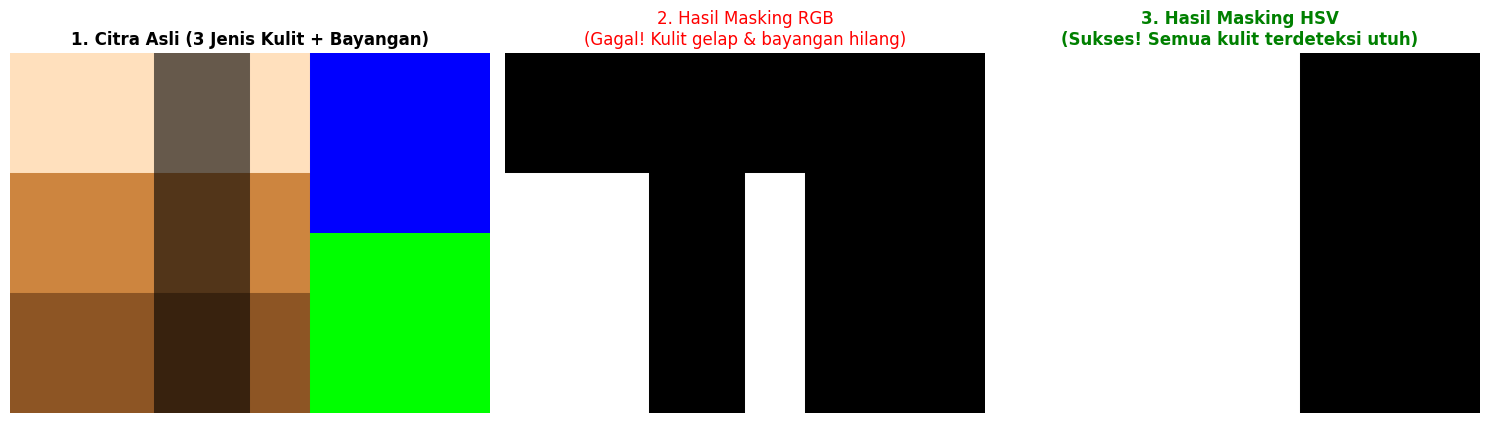

In [1]:
# ======================================================================
# PRAKTIKUM PERTEMUAN 6: COLOR SPACE & MASKING
# Skenario: Membuktikan bahwa HSV lebih kebal terhadap bayangan (Illumination)
#           dibandingkan RGB dalam kasus Deteksi Kulit (Skin Detection).
# ======================================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Membuat simulasi objek warna...")

# ----------------------------------------------------------------------
# 1. PERSIAPAN DATA (Mensintesis 3 Jenis Kulit + Objek Lain + Bayangan)
# ----------------------------------------------------------------------
# Membuat kanvas kosong (300 baris, 400 kolom, 3 channel warna BGR)
citra_bgr = np.zeros((300, 400, 3), dtype=np.uint8)

# Mensimulasikan 3 jenis warna kulit manusia (Warna direpresentasikan dalam BGR untuk OpenCV)
citra_bgr[0:100, 0:250]   = [189, 224, 255]  # Kulit Terang (Light)
citra_bgr[100:200, 0:250] = [63, 133, 205]   # Kulit Sawo Matang (Medium)
citra_bgr[200:300, 0:250] = [36, 85, 141]    # Kulit Gelap (Dark)

# Mensimulasikan objek non-kulit di sebelah kanan (sebagai pengecoh/noise)
citra_bgr[0:150, 250:400] = [255, 0, 0]      # Baju Biru Murni
citra_bgr[150:300, 250:400] = [0, 255, 0]    # Baju Hijau Murni

# MENSIMULASIKAN PERUBAHAN CAHAYA (Efek Bayangan / Shadow)
# Kita gelapkan 60% area tengah gambar untuk membuktikan kelemahan RGB
citra_bgr[:, 120:200] = citra_bgr[:, 120:200] * 0.4

# Konversi BGR ke RGB khusus untuk ditampilkan oleh Matplotlib dengan warna yang benar
citra_rgb_tampil = cv2.cvtColor(citra_bgr, cv2.COLOR_BGR2RGB)

# ----------------------------------------------------------------------
# 2. EKSPERIMEN 1: MASKING DENGAN RGB
# ----------------------------------------------------------------------
# Sangat sulit menentukan rentang RGB yang pas untuk semua kulit,
# apalagi yang terkena bayangan. Kita coba tebak rentang untuk kulit secara umum:
batas_bawah_rgb = np.array([30, 80, 120]) # R, G, B terendah
batas_atas_rgb = np.array([160, 220, 255]) # R, G, B tertinggi
mask_rgb = cv2.inRange(citra_bgr, batas_bawah_rgb, batas_atas_rgb)

# ----------------------------------------------------------------------
# 3. EKSPERIMEN 2: MASKING DENGAN HSV (The Holy Grail)
# ----------------------------------------------------------------------
# Konversi citra ke ruang warna HSV
citra_hsv = cv2.cvtColor(citra_bgr, cv2.COLOR_BGR2HSV)

# Aturan Emas Deteksi Kulit: Pigmen melanin berkumpul di Hue 0 hingga 20 (Oranye kemerahan).
# Kita biarkan Saturation dan Value rentangnya sangat lebar agar bayangan tetap terdeteksi!
batas_bawah_hsv = np.array([0, 30, 30])    # Hue mulai dari 0, Sat/Val minimal 30
batas_atas_hsv = np.array([20, 255, 255])  # Hue maksimal 20, Sat/Val maksimal 255

mask_hsv = cv2.inRange(citra_hsv, batas_bawah_hsv, batas_atas_hsv)

# ----------------------------------------------------------------------
# 4. VISUALISASI HASIL PERBANDINGAN
# ----------------------------------------------------------------------
plt.figure(figsize=(15, 5))

# Panel 1: Citra Asli
plt.subplot(1, 3, 1)
plt.title("1. Citra Asli (3 Jenis Kulit + Bayangan)", fontweight='bold')
plt.imshow(citra_rgb_tampil)
plt.axis('off')

# Panel 2: Hasil RGB
plt.subplot(1, 3, 2)
plt.title("2. Hasil Masking RGB\n(Gagal! Kulit gelap & bayangan hilang)", color='red')
plt.imshow(mask_rgb, cmap='gray')
plt.axis('off')

# Panel 3: Hasil HSV
plt.subplot(1, 3, 3)
plt.title("3. Hasil Masking HSV\n(Sukses! Semua kulit terdeteksi utuh)", color='green', fontweight='bold')
plt.imshow(mask_hsv, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

### Tugas mandiri:
1. Coba ubah warna objek pengecoh (Baju Biru/Hijau) pada baris kode simulasi menjadi warna Merah Murni ([0, 0, 255] dalam BGR). Apa yang terjadi pada hasil Masking HSV? Mengapa baju merah tersebut tiba-tiba ikut terdeteksi sebagai 'Kulit'? Modifikasi batas atas/bawah array HSV pada baris kode untuk mengatasi masalah false positive ini!" (Kunci jawaban untuk Anda: Baju merah akan terdeteksi karena warna merah murni memiliki Hue = $0^\circ$, yang masuk ke dalam rentang kulit. Solusinya, mahasiswa harus menganalisis bahwa baju merah memiliki Saturation (S) yang sangat pekat/tinggi (sekitar 255). Untuk membuang baju merah, mahasiswa harus menurunkan batas atas array pada komponen Saturation, misalnya menjadi [20, 180, 255] untuk memastikan warna yang terlalu "mencolok" tidak dianggap sebagai kulit manusia).
2. Foto seluruh mahasiswa yang hadir pada pertemuan hari ini dari depan kelas, lalu ganti seluruh warna kulit wajah menjadi hijau

### Tugas Mandiri 1

Membuat simulasi objek warna...


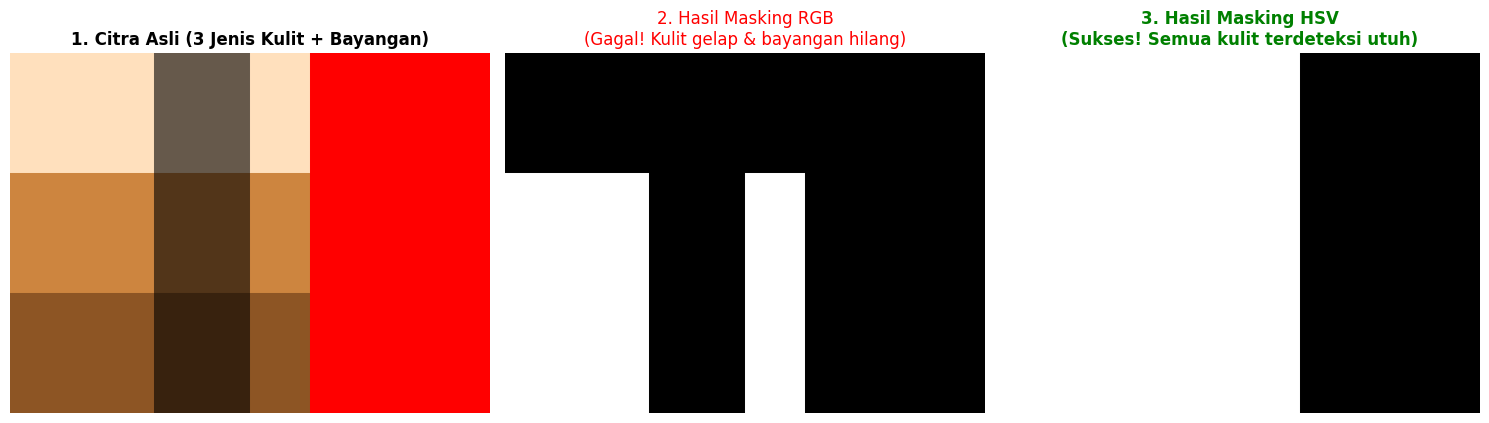

In [8]:
# ======================================================================
# PRAKTIKUM PERTEMUAN 6: COLOR SPACE & MASKING
# Skenario: Membuktikan bahwa HSV lebih kebal terhadap bayangan (Illumination)
#           dibandingkan RGB dalam kasus Deteksi Kulit (Skin Detection).
# ======================================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Membuat simulasi objek warna...")

# ----------------------------------------------------------------------
# 1. PERSIAPAN DATA (Mensintesis 3 Jenis Kulit + Objek Lain + Bayangan)
# ----------------------------------------------------------------------
# Membuat kanvas kosong (300 baris, 400 kolom, 3 channel warna BGR)
citra_bgr = np.zeros((300, 400, 3), dtype=np.uint8)

# Mensimulasikan 3 jenis warna kulit manusia (Warna direpresentasikan dalam BGR untuk OpenCV)
citra_bgr[0:100, 0:250]   = [189, 224, 255]  # Kulit Terang (Light)
citra_bgr[100:200, 0:250] = [63, 133, 205]   # Kulit Sawo Matang (Medium)
citra_bgr[200:300, 0:250] = [36, 85, 141]    # Kulit Gelap (Dark)

# Mensimulasikan objek non-kulit di sebelah kanan (sebagai pengecoh/noise)
citra_bgr[0:150, 250:400] = [0, 0, 255]      # Baju Biru Murni
citra_bgr[150:300, 250:400] = [0, 0, 255]    # Baju Hijau Murni

# MENSIMULASIKAN PERUBAHAN CAHAYA (Efek Bayangan / Shadow)
# Kita gelapkan 60% area tengah gambar untuk membuktikan kelemahan RGB
citra_bgr[:, 120:200] = citra_bgr[:, 120:200] * 0.4

# Konversi BGR ke RGB khusus untuk ditampilkan oleh Matplotlib dengan warna yang benar
citra_rgb_tampil = cv2.cvtColor(citra_bgr, cv2.COLOR_BGR2RGB)

# ----------------------------------------------------------------------
# 2. EKSPERIMEN 1: MASKING DENGAN RGB
# ----------------------------------------------------------------------
# Sangat sulit menentukan rentang RGB yang pas untuk semua kulit,
# apalagi yang terkena bayangan. Kita coba tebak rentang untuk kulit secara umum:
batas_bawah_rgb = np.array([30, 80, 120]) # R, G, B terendah
batas_atas_rgb = np.array([160, 220, 255]) # R, G, B tertinggi
mask_rgb = cv2.inRange(citra_bgr, batas_bawah_rgb, batas_atas_rgb)

# ----------------------------------------------------------------------
# 3. EKSPERIMEN 2: MASKING DENGAN HSV (The Holy Grail)
# ----------------------------------------------------------------------
# Konversi citra ke ruang warna HSV
citra_hsv = cv2.cvtColor(citra_bgr, cv2.COLOR_BGR2HSV)

# Aturan Emas Deteksi Kulit: Pigmen melanin berkumpul di Hue 0 hingga 20 (Oranye kemerahan).
# Kita biarkan Saturation dan Value rentangnya sangat lebar agar bayangan tetap terdeteksi!
batas_bawah_hsv = np.array([0, 30, 30])    # Hue mulai dari 0, Sat/Val minimal 30
batas_atas_hsv = np.array([20, 220, 255])  # Hue maksimal 20, Sat/Val maksimal 255

mask_hsv = cv2.inRange(citra_hsv, batas_bawah_hsv, batas_atas_hsv)

# ----------------------------------------------------------------------
# 4. VISUALISASI HASIL PERBANDINGAN
# ----------------------------------------------------------------------
plt.figure(figsize=(15, 5))

# Panel 1: Citra Asli
plt.subplot(1, 3, 1)
plt.title("1. Citra Asli (3 Jenis Kulit + Bayangan)", fontweight='bold')
plt.imshow(citra_rgb_tampil)
plt.axis('off')

# Panel 2: Hasil RGB
plt.subplot(1, 3, 2)
plt.title("2. Hasil Masking RGB\n(Gagal! Kulit gelap & bayangan hilang)", color='red')
plt.imshow(mask_rgb, cmap='gray')
plt.axis('off')

# Panel 3: Hasil HSV
plt.subplot(1, 3, 3)
plt.title("3. Hasil Masking HSV\n(Sukses! Semua kulit terdeteksi utuh)", color='green', fontweight='bold')
plt.imshow(mask_hsv, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

### Tugas Mandiri 2

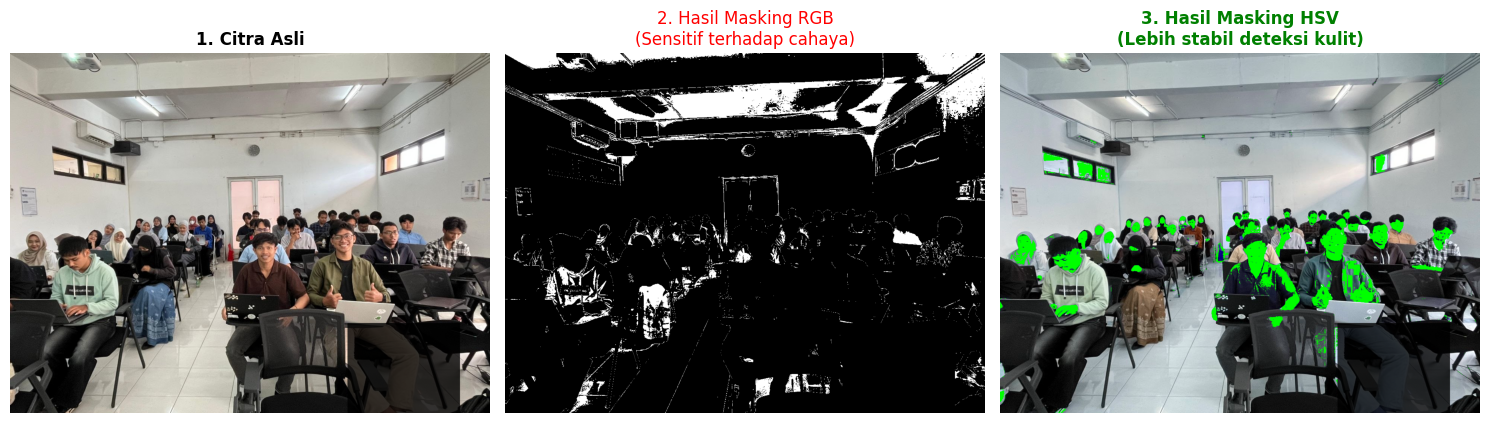

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Import gambar
gambar_bgr = cv2.imread('kelas.jpg')
gambar_bgr[720:960, 900:1200] = gambar_bgr[720:960, 900:1200] * 0.2  # Simulasi bayangan dengan menggelapkan area bawah
gambar_rgb_display = cv2.cvtColor(gambar_bgr, cv2.COLOR_BGR2RGB)

# 2. Masking RGB (Menggunakan urutan BGR sesuai OpenCV)
batas_bawah_rgb = np.array([120, 80, 30]) 
batas_atas_rgb = np.array([255, 220, 160]) 
mask_rgb = cv2.inRange(gambar_bgr, batas_bawah_rgb, batas_atas_rgb)

# 3. Masking HSV
gambar_hsv = cv2.cvtColor(gambar_bgr, cv2.COLOR_BGR2HSV)
# Hue untuk warna kulit di rentang 0-20
batas_bawah_hsv = np.array([0, 58, 60])    
batas_atas_hsv = np.array([20, 160, 255])  
mask_hsv = cv2.inRange(gambar_hsv, batas_bawah_hsv, batas_atas_hsv)
citra_hasil = gambar_bgr.copy()
citra_hasil[mask_hsv == 255] = [0, 255, 0]

# 4. Visualisasi
plt.figure(figsize=(15, 5))

# Panel 1: Citra Asli (Sudah dikonversi ke RGB)
plt.subplot(1, 3, 1)
plt.title("1. Citra Asli", fontweight='bold')
plt.imshow(gambar_rgb_display)
plt.axis('off')

# Panel 2: Hasil RGB
plt.subplot(1, 3, 2)
plt.title("2. Hasil Masking RGB\n(Sensitif terhadap cahaya)", color='red')
plt.imshow(mask_rgb, cmap='gray')
plt.axis('off')

# Panel 3: Hasil HSV
plt.subplot(1, 3, 3)
plt.title("3. Hasil Masking HSV\n(Lebih stabil deteksi kulit)", color='green', fontweight='bold')
plt.imshow(citra_hasil, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()